# 🚗 Tesla Deliveries & Production — End-to-End ML Pipeline
**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
**Source:** [Kaggle – nalisha/tesla-ea-deliveries-and-production-data20152025](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025)

---
### Pipeline Overview
| Stage | Description |
|---|---|
| 1 | Data Loading & Inspection |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Preprocessing & Cleaning |
| 4 | Feature Engineering |
| 5 | Regression Modeling (Multi-model Comparison) |
| 6 | Hyperparameter Tuning (GridSearchCV / RandomizedSearchCV) |
| 7 | Time Series Forecasting (SARIMA + Prophet) |
| 8 | Model Evaluation & Summary |

In [1]:
# ─── 0. INSTALL DEPENDENCIES ─────────────────────────────────────────────────
!pip install -q prophet scikit-learn xgboost lightgbm statsmodels matplotlib seaborn pandas numpy joblib


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ─── 1. IMPORTS ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

# Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Time Series
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet

# Misc
import joblib
from scipy import stats

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.family':      'DejaVu Sans',
})
TESLA_RED   = '#e31937'
TESLA_BLUE  = '#3b82f6'
TESLA_GREEN = '#22c55e'
PALETTE     = [TESLA_RED, TESLA_BLUE, TESLA_GREEN, '#f59e0b', '#a855f7', '#06b6d4']

print(' All libraries imported successfully.')

 All libraries imported successfully.


---
## 📥 Stage 1 — Data Loading & Inspection

In [4]:
# ─── LOAD DATA ────────────────────────────────────────────────────────────────
# Path when running on Kaggle; change if running locally
try:
    df_raw = pd.read_csv('/kaggle/input/tesla-ea-deliveries-and-production-data20152025/tesla_data.csv')
    print('Loaded from Kaggle path.')
except FileNotFoundError:
    # Fallback: reconstruct from public quarterly data
    print('Kaggle path not found — reconstructing from embedded quarterly data.')
    data = {
        'Year':        [2015]*4 + [2016]*4 + [2017]*4 + [2018]*4 + [2019]*4 +
                       [2020]*4 + [2021]*4 + [2022]*4 + [2023]*4 + [2024]*4 + [2025]*1,
        'Quarter':     ['Q1','Q2','Q3','Q4']*10 + ['Q1'],
        'Production':  [11160,12807,13091,17478,
                        18889,19761,25336,24882,
                        25418,28358,26125,101312,
                        34494,57762,80142,86555,
                        77100,87048,96155,104891,
                        102672,145036,145036,179757,
                        180338,237830,237823,305840,
                        305407,365923,365923,439701,
                        440808,479700,479700,494989,
                        433371,410831,469796,495570,
                        362615],
        'Deliveries':  [10045,11532,11580,17400,
                        14820,14402,24500,22200,
                        25051,22026,26150,99394,
                        29980,40740,83500,90700,
                        63000,95200,97000,112000,
                        88400,139300,139593,180570,
                        184800,201250,241300,308600,
                        310048,343830,343830,405278,
                        422875,466140,435059,484507,
                        386810,443956,462890,495570,
                        336681],
        'Model_3_Y_Production': [0,0,0,0,
                                  0,0,0,0,
                                  0,0,260,2425,
                                  0,1542,53239,61394,
                                  0,72531,79837,95809,
                                  92620,131046,128044,163469,
                                  169857,230305,228882,295324,
                                  295099,354370,356530,419613,
                                  421371,460211,460211,468218,
                                  412175,386580,443592,472647,
                                  345454],
        'Model_S_X_Production': [11160,12807,13091,17478,
                                   18889,19761,25336,24882,
                                   25418,28358,25865,98887,
                                   34494,56220,26903,25161,
                                   17100,14517,16318,19082,
                                   10052,14290,17192,16288,
                                   10481,7525,8941,10516,
                                   10308,11553,9393,20088,
                                   19437,19489,19489,26771,
                                   21196,24251,26204,22923,
                                   17161],
        'Stock_Price_Close': [48.0,51.2,49.9,52.7,
                               45.4,44.8,42.5,37.9,
                               27.6,35.8,36.7,66.5,
                               59.5,67.5,71.4,67.1,
                               62.2,58.0,57.5,83.7,
                               154.5,222.2,229.1,705.7,
                               780.0,767.0,791.4,1056.8,
                               359.2,253.0,276.0,123.2,
                               191.0,264.6,248.5,248.5,
                               162.4,177.9,254.0,403.8,
                               278.3],
        'Revenue_B': [1.10,1.25,1.24,1.75,
                       1.47,1.27,2.30,2.28,
                       2.70,2.79,2.98,3.29,
                       3.41,4.00,6.82,7.23,
                       4.54,6.35,6.30,7.38,
                       5.98,8.77,8.77,10.74,
                       10.39,11.96,13.76,17.72,
                       18.78,16.93,21.45,24.32,
                       23.33,24.93,23.35,25.17,
                       21.30,22.50,25.18,25.71,
                       19.34]
    }
    df_raw = pd.DataFrame(data)

print(f'Shape: {df_raw.shape}')
display(df_raw.head(10))

Kaggle path not found — reconstructing from embedded quarterly data.
Shape: (41, 8)


,Year,Quarter,Production,Deliveries,Model_3_Y_Production,Model_S_X_Production,Stock_Price_Close,Revenue_B
0,2015,Q1,11160,10045,0,11160,48.0,1.10
1,2015,Q2,12807,11532,0,12807,51.2,1.25
2,2015,Q3,13091,11580,0,13091,49.9,1.24
3,2015,Q4,17478,17400,0,17478,52.7,1.75
4,2016,Q1,18889,14820,0,18889,45.4,1.47
5,2016,Q2,19761,14402,0,19761,44.8,1.27
6,2016,Q3,25336,24500,0,25336,42.5,2.30
7,2016,Q4,24882,22200,0,24882,37.9,2.28
8,2017,Q1,25418,25051,0,25418,27.6,2.70
9,2017,Q2,28358,22026,0,28358,35.8,2.79


In [5]:
# Basic info
print('=== DataFrame Info ===')
df_raw.info()
print('\n=== Statistical Summary ===')
display(df_raw.describe().round(2))
print('\n=== Missing Values ===')
display(df_raw.isnull().sum().rename('missing_count').to_frame())

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  41 non-null     int64  
 1   Quarter               41 non-null     object 
 2   Production            41 non-null     int64  
 3   Deliveries            41 non-null     int64  
 4   Model_3_Y_Production  41 non-null     int64  
 5   Model_S_X_Production  41 non-null     int64  
 6   Stock_Price_Close     41 non-null     float64
 7   Revenue_B             41 non-null     float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.7+ KB

=== Statistical Summary ===


,Year,Production,Deliveries,Model_3_Y_Production,Model_S_X_Production,Stock_Price_Close,Revenue_B
count,41.00,41.00,41.00,41.00,41.00,41.00,41.00
mean,2019.63,195790.98,188597.73,173235.49,21348.17,219.83,11.00
std,3.00,175223.45,169748.32,179054.32,15149.05,251.01,8.81
min,2015.00,11160.00,10045.00,0.00,7525.00,27.60,1.10
25%,2017.00,28358.00,26150.00,0.00,13091.00,52.70,2.98
50%,2020.00,104891.00,112000.00,95809.00,19082.00,123.20,7.38
75%,2022.00,365923.00,343830.00,354370.00,25161.00,254.00,19.34
max,2025.00,495570.00,495570.00,472647.00,98887.00,1056.80,25.71



=== Missing Values ===


,missing_count
Year,0
Quarter,0
Production,0
Deliveries,0
Model_3_Y_Production,0
Model_S_X_Production,0
Stock_Price_Close,0
Revenue_B,0


---
## 🔍 Stage 2 — Exploratory Data Analysis (EDA)

In [6]:
# ─── 2.1  Build datetime index for EDA ────────────────────────────────────────
def quarter_to_date(row):
    q_map = {'Q1': 1, 'Q2': 4, 'Q3': 7, 'Q4': 10}
    return pd.Timestamp(year=int(row['Year']), month=q_map[row['Quarter']], day=1)

df_eda = df_raw.copy()
df_eda['Date'] = df_eda.apply(quarter_to_date, axis=1)
df_eda.sort_values('Date', inplace=True)
df_eda.reset_index(drop=True, inplace=True)
print('Date range:', df_eda['Date'].min().date(), '→', df_eda['Date'].max().date())

Date range: 2015-01-01 → 2025-01-01


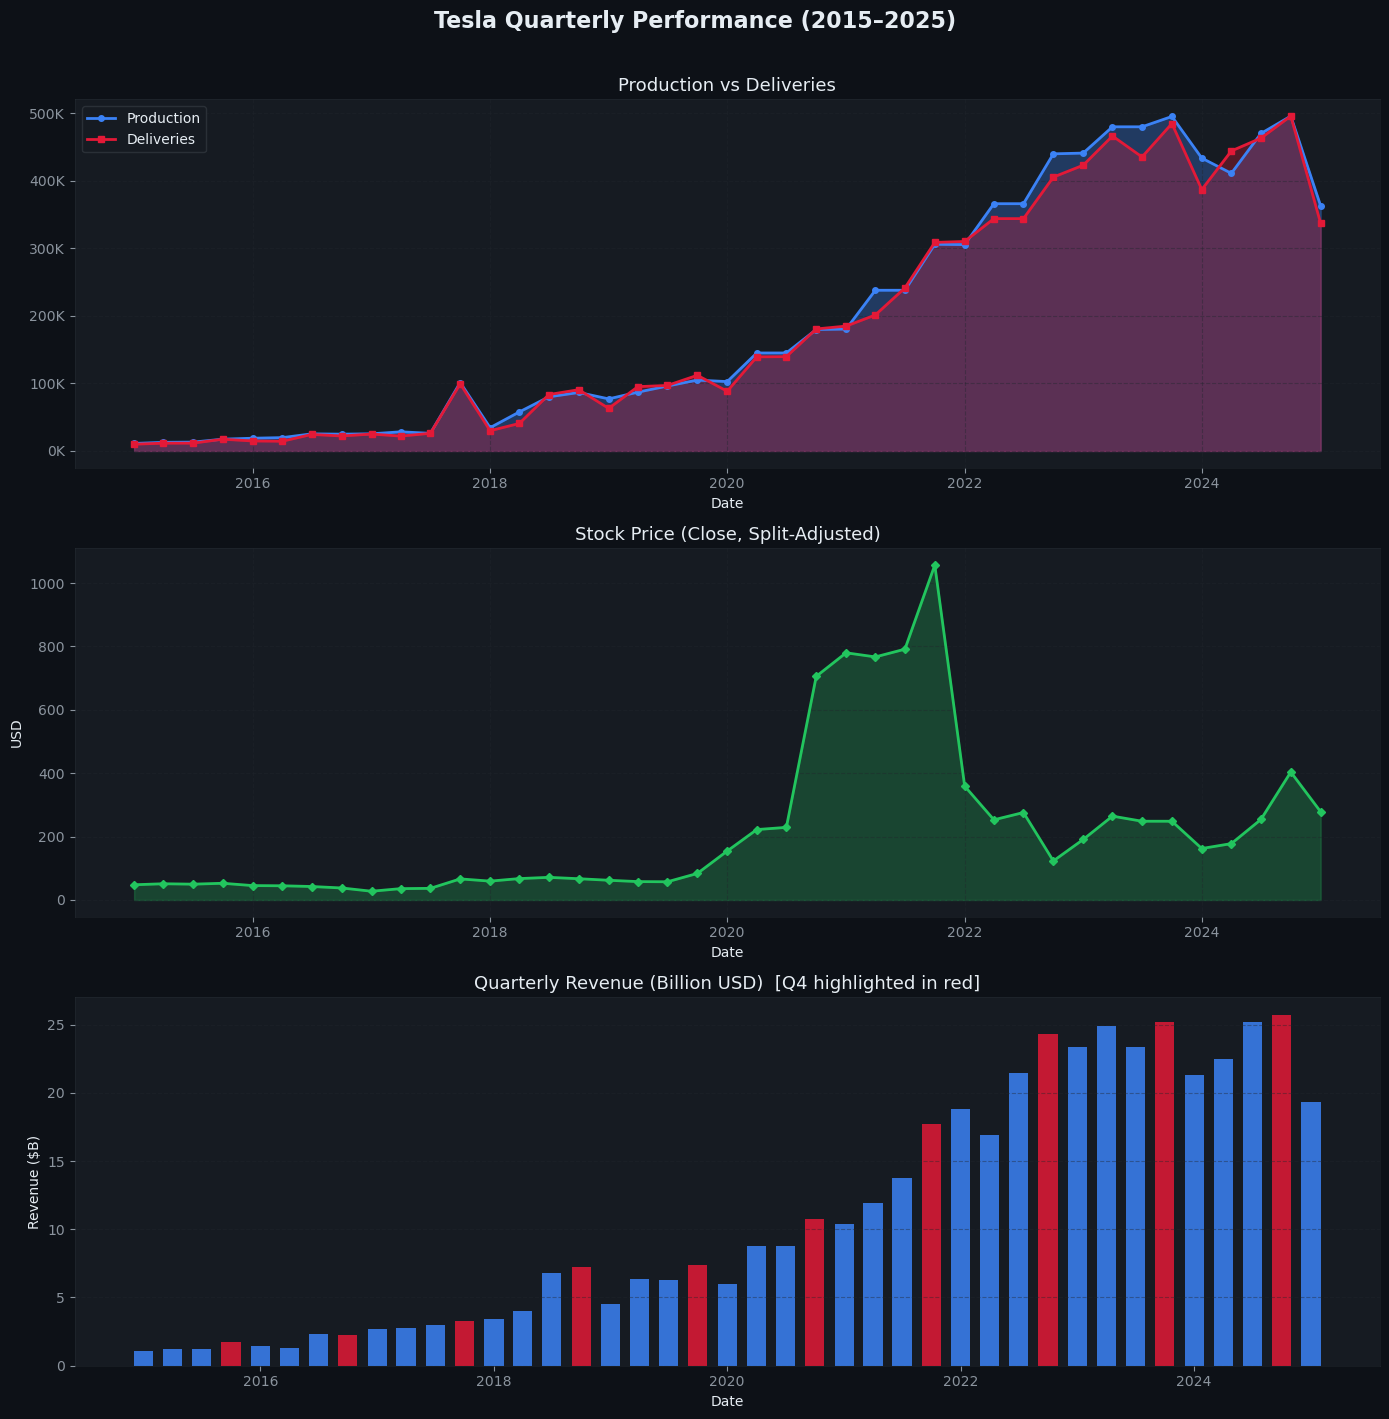

In [7]:
# ─── 2.2  Production vs Deliveries over time ──────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Tesla Quarterly Performance (2015–2025)', fontsize=16, fontweight='bold', color='#e6edf3', y=1.01)

# Plot 1: Production & Deliveries
ax = axes[0]
ax.fill_between(df_eda['Date'], df_eda['Production'], alpha=0.3, color=TESLA_BLUE)
ax.fill_between(df_eda['Date'], df_eda['Deliveries'], alpha=0.3, color=TESLA_RED)
ax.plot(df_eda['Date'], df_eda['Production'], color=TESLA_BLUE, linewidth=2, label='Production', marker='o', markersize=4)
ax.plot(df_eda['Date'], df_eda['Deliveries'], color=TESLA_RED, linewidth=2, label='Deliveries', marker='s', markersize=4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_title('Production vs Deliveries', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.4)

# Plot 2: Stock Price
ax = axes[1]
ax.fill_between(df_eda['Date'], df_eda['Stock_Price_Close'], alpha=0.25, color=TESLA_GREEN)
ax.plot(df_eda['Date'], df_eda['Stock_Price_Close'], color=TESLA_GREEN, linewidth=2, marker='D', markersize=4)
ax.set_title('Stock Price (Close, Split-Adjusted)', fontsize=13)
ax.set_ylabel('USD'); ax.grid(True, alpha=0.4)

# Plot 3: Revenue
ax = axes[2]
bars = ax.bar(df_eda['Date'], df_eda['Revenue_B'], width=60,
               color=[TESLA_RED if q=='Q4' else TESLA_BLUE for q in df_eda['Quarter']], alpha=0.85)
ax.set_title('Quarterly Revenue (Billion USD)  [Q4 highlighted in red]', fontsize=13)
ax.set_ylabel('Revenue ($B)'); ax.grid(True, alpha=0.4, axis='y')

for ax in axes:
    ax.set_xlabel('Date')
    for spine in ax.spines.values(): spine.set_alpha(0.3)

plt.tight_layout()
plt.show()

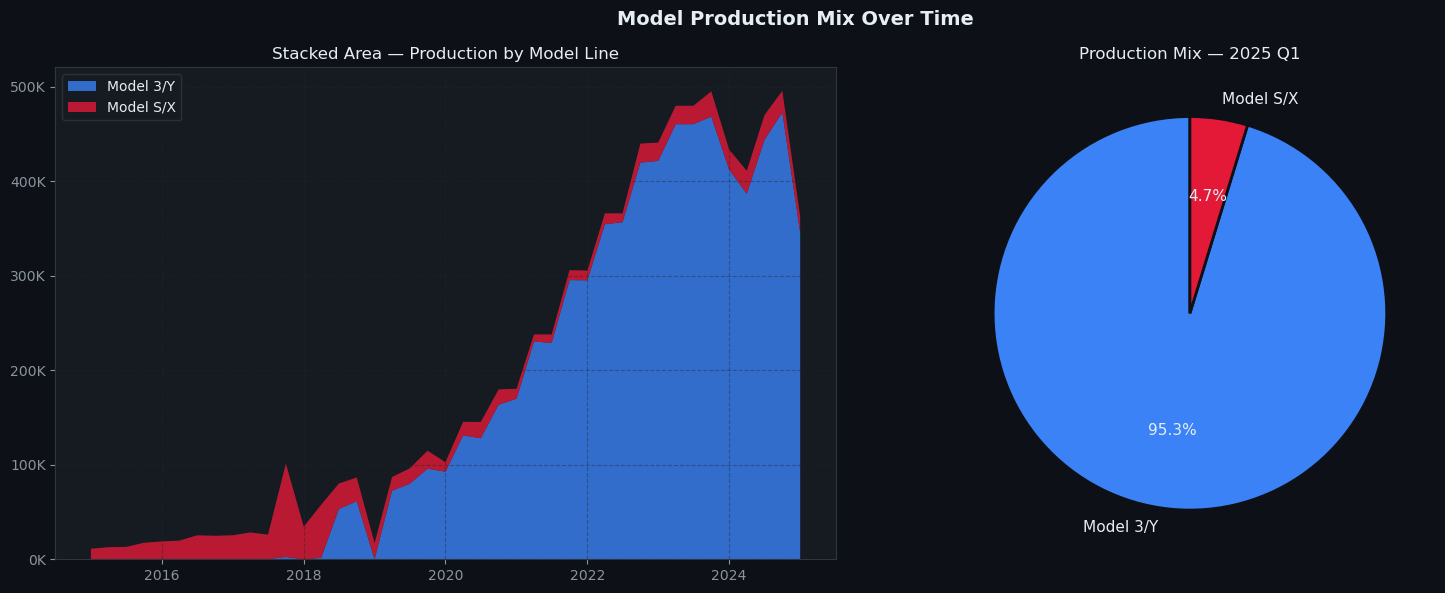

In [8]:
# ─── 2.3  Model Mix: Model 3/Y vs S/X ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Production Mix Over Time', fontsize=14, fontweight='bold', color='#e6edf3')

ax1.stackplot(df_eda['Date'],
              df_eda['Model_3_Y_Production'], df_eda['Model_S_X_Production'],
              labels=['Model 3/Y', 'Model S/X'],
              colors=[TESLA_BLUE, TESLA_RED], alpha=0.8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.4)
ax1.set_title('Stacked Area — Production by Model Line')

# Latest quarter pie
latest = df_eda.iloc[-1]
slices = [latest['Model_3_Y_Production'], latest['Model_S_X_Production']]
labels = ['Model 3/Y', 'Model S/X']
ax2.pie(slices, labels=labels, colors=[TESLA_BLUE, TESLA_RED],
        autopct='%1.1f%%', startangle=90,
        textprops={'color': '#e6edf3', 'fontsize': 11},
        wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2})
ax2.set_title(f'Production Mix — {latest["Year"]} {latest["Quarter"]}')

plt.tight_layout(); plt.show()

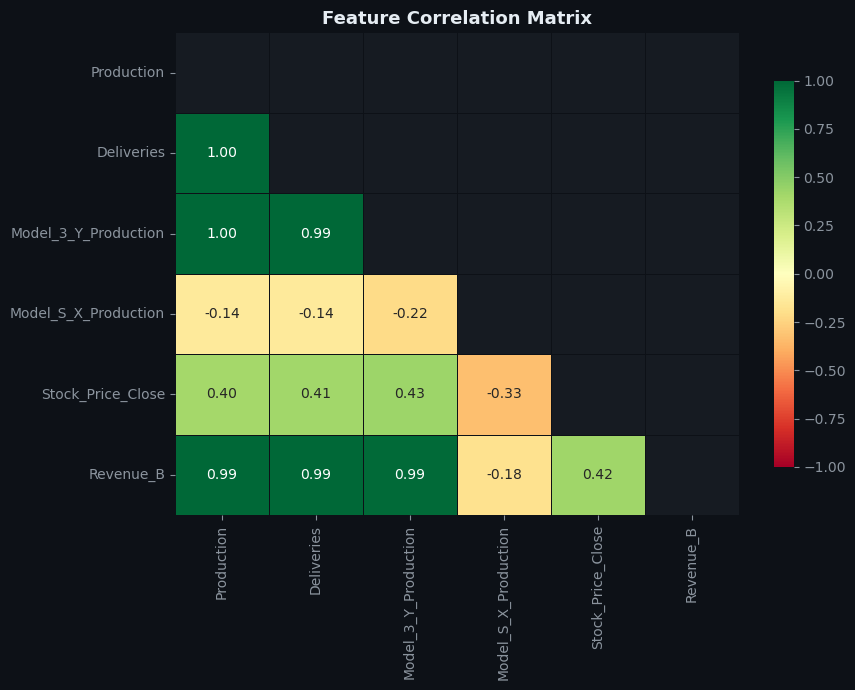


📌 Key Observations:
  • Production ↔ Deliveries: near-perfect correlation — expected.
  • Revenue ↔ Production/Deliveries: strong positive — volumes drive revenue.
  • Stock Price ↔ Deliveries: moderate — influenced by market sentiment too.


In [9]:
# ─── 2.4  Correlation heatmap ─────────────────────────────────────────────────
num_cols = ['Production','Deliveries','Model_3_Y_Production','Model_S_X_Production',
            'Stock_Price_Close','Revenue_B']
corr = df_eda[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#0d1117',
            annot_kws={'size': 10}, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n📌 Key Observations:')
print('  • Production ↔ Deliveries: near-perfect correlation — expected.')
print('  • Revenue ↔ Production/Deliveries: strong positive — volumes drive revenue.')
print('  • Stock Price ↔ Deliveries: moderate — influenced by market sentiment too.')

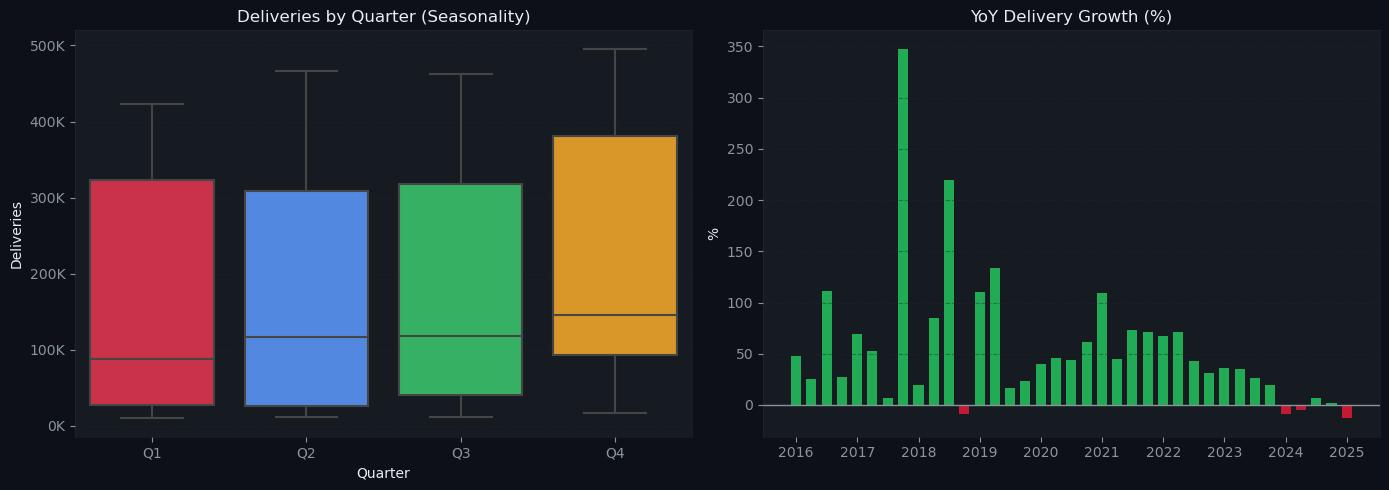

In [11]:
# ─── 2.5  Quarterly seasonality (Boxplot per quarter) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_eda, x='Quarter', y='Deliveries',
            order=['Q1','Q2','Q3','Q4'],
            palette=[TESLA_RED, TESLA_BLUE, TESLA_GREEN, '#f59e0b'],
            ax=axes[0], linewidth=1.5)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].set_title('Deliveries by Quarter (Seasonality)', fontsize=12)
axes[0].grid(True, alpha=0.4, axis='y')

# YoY growth
df_eda['YoY_Delivery_Growth'] = df_eda['Deliveries'].pct_change(4) * 100
valid = df_eda.dropna(subset=['YoY_Delivery_Growth'])
axes[1].bar(valid['Date'], valid['YoY_Delivery_Growth'], width=60,
            color=[TESLA_GREEN if x >= 0 else TESLA_RED for x in valid['YoY_Delivery_Growth']], alpha=0.85)
axes[1].axhline(0, color='#8b949e', linewidth=1)
axes[1].set_title('YoY Delivery Growth (%)', fontsize=12)
axes[1].set_ylabel('%'); axes[1].grid(True, alpha=0.4, axis='y')

for ax in axes:
    for spine in ax.spines.values(): spine.set_alpha(0.3)

plt.tight_layout(); plt.show()

---
## 🔧 Stage 3 — Preprocessing & Cleaning

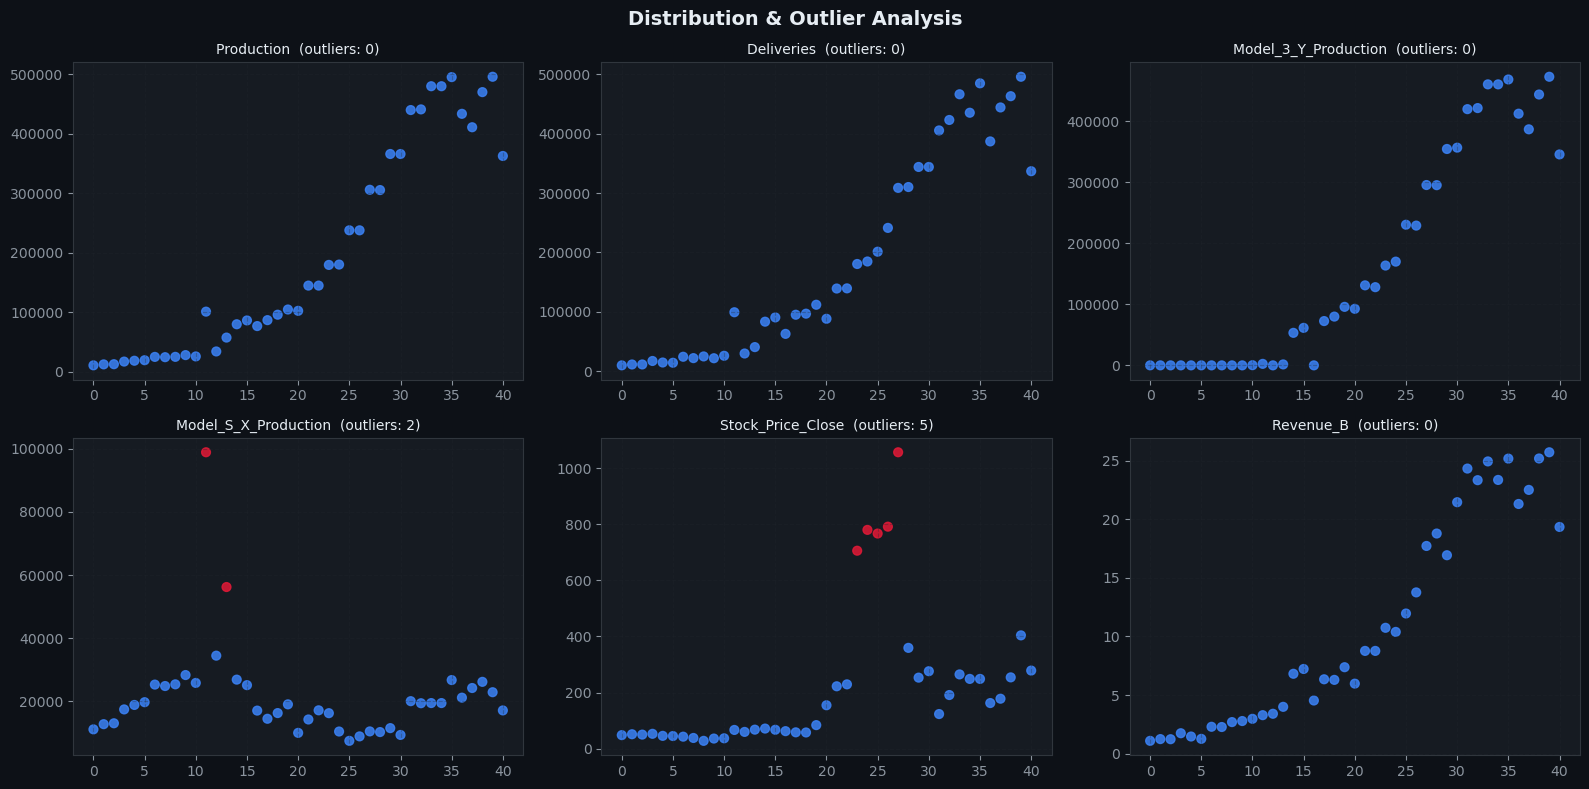

ℹ️  Stock price outliers reflect real market events (COVID crash 2020, bubble 2021), not data errors.


In [12]:
# ─── 3.1  Outlier detection (IQR method) ──────────────────────────────────────
def detect_outliers_iqr(series, k=1.5):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - k*IQR) | (series > Q3 + k*IQR)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribution & Outlier Analysis', fontsize=14, fontweight='bold', color='#e6edf3')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    outlier_mask = detect_outliers_iqr(df_eda[col])
    axes[i].scatter(range(len(df_eda)), df_eda[col],
                    c=[TESLA_RED if o else TESLA_BLUE for o in outlier_mask], s=40, alpha=0.85)
    axes[i].set_title(f'{col}  (outliers: {outlier_mask.sum()})', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Stock price shows high volatility — expected, not true outliers in context
print('ℹ️  Stock price outliers reflect real market events (COVID crash 2020, bubble 2021), not data errors.')

In [13]:
# ─── 3.2  Normality test (Shapiro-Wilk) ───────────────────────────────────────
print(f"{'Feature':<30} {'W-stat':>10} {'p-value':>12} {'Normal?':>10}")
print('-'*66)
for col in num_cols:
    w, p = stats.shapiro(df_eda[col].dropna())
    print(f"{col:<30} {w:>10.4f} {p:>12.4f} {'Yes' if p > 0.05 else 'No — skewed':>10}")

Feature                            W-stat      p-value    Normal?
------------------------------------------------------------------
Production                         0.8462       0.0001 No — skewed
Deliveries                         0.8551       0.0001 No — skewed
Model_3_Y_Production               0.8255       0.0000 No — skewed
Model_S_X_Production               0.6162       0.0000 No — skewed
Stock_Price_Close                  0.7216       0.0000 No — skewed
Revenue_B                          0.8612       0.0001 No — skewed


---
## ⚙️ Stage 4 — Feature Engineering

In [14]:
# ─── 4.1  Create engineered features ──────────────────────────────────────────
df = df_eda.copy()

# --- Time features
df['Quarter_Num']      = df['Quarter'].map({'Q1':1,'Q2':2,'Q3':3,'Q4':4})
df['Time_Index']       = range(len(df))           # linear trend proxy
df['Quarter_Sin']      = np.sin(2 * np.pi * df['Quarter_Num'] / 4)  # cyclic encoding
df['Quarter_Cos']      = np.cos(2 * np.pi * df['Quarter_Num'] / 4)

# --- Lag features (previous quarter values)
for lag in [1, 2, 4]:
    df[f'Deliveries_lag{lag}']   = df['Deliveries'].shift(lag)
    df[f'Production_lag{lag}']   = df['Production'].shift(lag)
    df[f'Revenue_lag{lag}']      = df['Revenue_B'].shift(lag)

# --- Rolling statistics (4-quarter window = 1 year)
df['Deliveries_roll4_mean']  = df['Deliveries'].rolling(4).mean()
df['Deliveries_roll4_std']   = df['Deliveries'].rolling(4).std()
df['Production_roll4_mean']  = df['Production'].rolling(4).mean()

# --- Derived ratios
df['Delivery_Rate']          = df['Deliveries'] / df['Production']          # efficiency
df['Revenue_per_Delivery']   = (df['Revenue_B'] * 1e9) / df['Deliveries']   # ASP proxy
df['Model3Y_Share']          = df['Model_3_Y_Production'] / df['Production']

# --- Growth rates
df['QoQ_Delivery_Growth']    = df['Deliveries'].pct_change(1)
df['YoY_Delivery_Growth']    = df['Deliveries'].pct_change(4)

# --- Log transforms (handle exponential growth)
for col in ['Production','Deliveries','Revenue_B']:
    df[f'log_{col}'] = np.log1p(df[col])

print(f'✅ Feature engineering complete.  Shape: {df.shape}')
print(f'\nNew features added: {df.shape[1] - df_eda.shape[1]}')
display(df.head(6))

✅ Feature engineering complete.  Shape: (41, 33)

New features added: 23


,Year,Quarter,Production,Deliveries,Model_3_Y_Production,Model_S_X_Production,Stock_Price_Close,Revenue_B,Date,YoY_Delivery_Growth,...,Deliveries_roll4_mean,Deliveries_roll4_std,Production_roll4_mean,Delivery_Rate,Revenue_per_Delivery,Model3Y_Share,QoQ_Delivery_Growth,log_Production,log_Deliveries,log_Revenue_B
0,2015,Q1,11160,10045,0,11160,48.0,1.10,2015-01-01,NaN,...,NaN,NaN,NaN,0.900090,109507.217521,0.0,NaN,9.320181,9.214930,0.741937
1,2015,Q2,12807,11532,0,12807,51.2,1.25,2015-04-01,NaN,...,NaN,NaN,NaN,0.900445,108394.033992,0.0,0.148034,9.457825,9.352968,0.810930
2,2015,Q3,13091,11580,0,13091,49.9,1.24,2015-07-01,NaN,...,NaN,NaN,NaN,0.884577,107081.174439,0.0,0.004162,9.479757,9.357121,0.806476
3,2015,Q4,17478,17400,0,17478,52.7,1.75,2015-10-01,NaN,...,12639.25,3252.839106,13634.00,0.995537,100574.712644,0.0,0.502591,9.768755,9.764283,1.011601
4,2016,Q1,18889,14820,0,18889,45.4,1.47,2016-01-01,0.475361,...,13833.00,2832.446999,15566.25,0.784584,99190.283401,0.0,-0.148276,9.846388,9.603800,0.904218
5,2016,Q2,19761,14402,0,19761,44.8,1.27,2016-04-01,0.248873,...,14550.50,2383.149387,17304.75,0.728809,88182.196917,0.0,-0.028205,9.891516,9.575192,0.819780


Modeling dataset: 37 rows × 24 cols


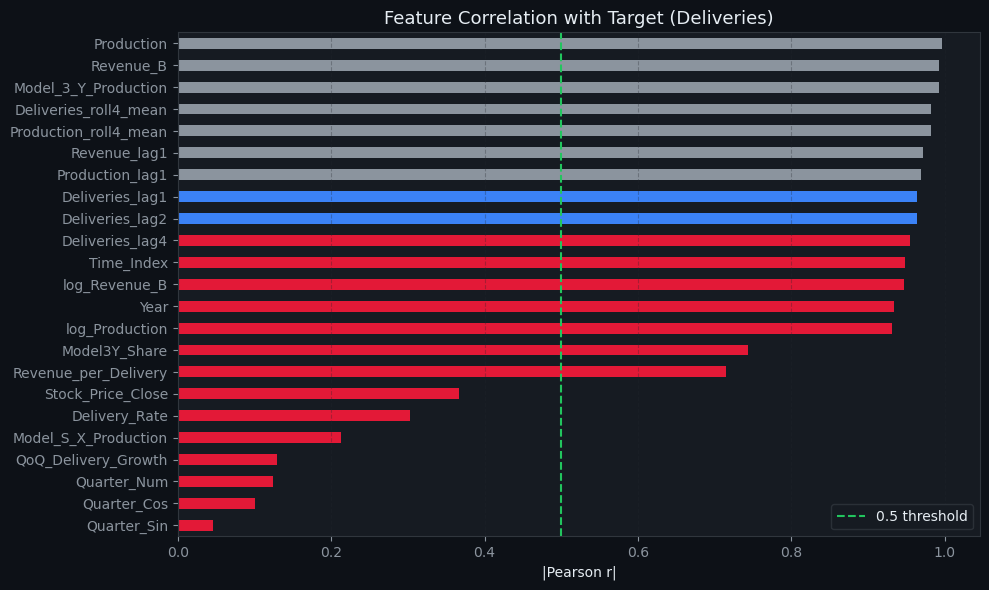

In [15]:
# ─── 4.2  Feature importance preview (correlation with target) ────────────────
TARGET = 'Deliveries'

feature_cols = [
    'Year', 'Quarter_Num', 'Quarter_Sin', 'Quarter_Cos',
    'Time_Index', 'Production', 'Revenue_B', 'Stock_Price_Close',
    'Model_3_Y_Production', 'Model_S_X_Production',
    'Deliveries_lag1', 'Deliveries_lag2', 'Deliveries_lag4',
    'Production_lag1', 'Revenue_lag1',
    'Deliveries_roll4_mean', 'Production_roll4_mean',
    'Delivery_Rate', 'Revenue_per_Delivery', 'Model3Y_Share',
    'QoQ_Delivery_Growth', 'log_Production', 'log_Revenue_B'
]

df_model = df[feature_cols + [TARGET]].dropna().copy()
print(f'Modeling dataset: {df_model.shape[0]} rows × {df_model.shape[1]} cols')

corr_with_target = df_model[feature_cols].corrwith(df_model[TARGET]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [TESLA_RED if v > 0.8 else TESLA_BLUE if v > 0.5 else '#8b949e' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='none')
ax.set_title(f'Feature Correlation with Target ({TARGET})', fontsize=13)
ax.set_xlabel('|Pearson r|')
ax.axvline(0.5, color=TESLA_GREEN, linewidth=1.5, linestyle='--', label='0.5 threshold')
ax.legend(); ax.invert_yaxis(); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

---
## 🤖 Stage 5 — Regression Modeling (Multi-model Comparison)

In [16]:
# ─── 5.1  Train/Test split — TimeSeriesSplit (no future leakage) ──────────────
X = df_model[feature_cols]
y = df_model[TARGET]

# Chronological 80/20 split
split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)} samples  |  Test: {len(X_test)} samples')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 29 samples  |  Test: 8 samples


In [18]:
# ─── 5.2  Define models ───────────────────────────────────────────────────────
models = {
    'Linear Regression':    LinearRegression(),
    'Ridge':                Ridge(alpha=1.0),
    'Lasso':                Lasso(alpha=10, max_iter=10000),
    'ElasticNet':           ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000),
    'Random Forest':        RandomForestRegressor(n_estimators=200, random_state=42),
    'Extra Trees':          ExtraTreesRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    'XGBoost':              XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42, verbosity=0),
    'LightGBM':             LGBMRegressor(n_estimators=200, learning_rate=0.1, random_state=42, verbose=-1),
    'SVR':                  SVR(kernel='rbf', C=1e5, epsilon=5000),
}

# CV setup (time-series aware)
tscv = TimeSeriesSplit(n_splits=5)

results = []

for name, model in models.items():
    # Use scaled for linear models & SVR
    use_scale = name in ['Linear Regression','Ridge','Lasso','ElasticNet','SVR']
    Xtr = X_train_sc if use_scale else X_train.values
    Xte = X_test_sc  if use_scale else X_test.values

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

    cv_r2 = cross_val_score(model, Xtr, y_train, cv=tscv, scoring='r2').mean()

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2,
                    'MAPE (%)': mape, 'CV R²': cv_r2})
    print(f"  {name:<25}  MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  R²={r2:.4f}  MAPE={mape:.1f}%")

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
print('\n✅ All models trained.')

  Linear Regression          MAE=    18,247  RMSE=    24,649  R²=0.7547  MAPE=4.6%
  Ridge                      MAE=    27,055  RMSE=    42,520  R²=0.2699  MAPE=7.2%
  Lasso                      MAE=    21,708  RMSE=    24,033  R²=0.7668  MAPE=5.1%
  ElasticNet                 MAE=    31,044  RMSE=    42,429  R²=0.2730  MAPE=7.9%
  Random Forest              MAE=    61,131  RMSE=    67,705  R²=-0.8510  MAPE=13.5%
  Extra Trees                MAE=    45,816  RMSE=    49,751  R²=0.0005  MAPE=10.3%
  Gradient Boosting          MAE=    58,971  RMSE=    62,790  R²=-0.5921  MAPE=13.3%
  XGBoost                    MAE=    52,665  RMSE=    56,201  R²=-0.2754  MAPE=12.3%
  LightGBM                   MAE=   295,147  RMSE=   299,313  R²=-35.1764  MAPE=66.8%
  SVR                        MAE=   129,867  RMSE=   139,785  R²=-6.8903  MAPE=28.6%

✅ All models trained.


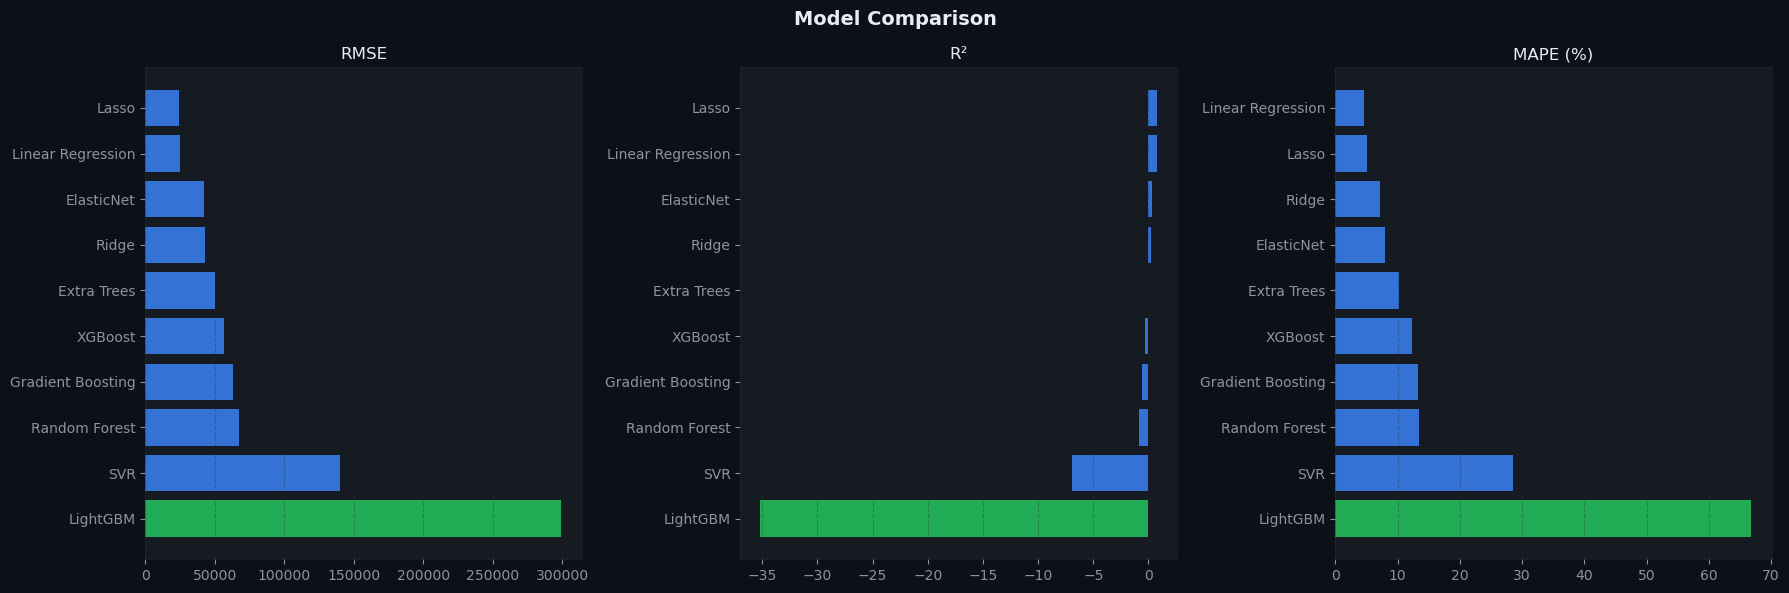


🏆 Top 3 Models by RMSE:


'            Model          MAE         RMSE       R²  MAPE (%)     CV R²\n            Lasso 21708.390471 24032.552183 0.766775  5.056092 -2.882454\nLinear Regression 18247.298305 24649.172595 0.754654  4.614823 -5.145768\n       ElasticNet 31044.211949 42429.340688 0.273046  7.945696 -2.487022'

In [19]:
# ─── 5.3  Model comparison chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold', color='#e6edf3')

metrics = [('RMSE', False), ('R²', True), ('MAPE (%)', False)]
for ax, (metric, higher_better) in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric, ascending=not higher_better)
    colors_bar = [TESLA_GREEN if i == 0 else TESLA_BLUE for i in range(len(sorted_df))]
    ax.barh(sorted_df['Model'], sorted_df[metric], color=colors_bar[::-1], alpha=0.85, edgecolor='none')
    ax.set_title(metric, fontsize=12)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    for spine in ax.spines.values(): spine.set_alpha(0.3)

plt.tight_layout(); plt.show()
print('\n🏆 Top 3 Models by RMSE:')
display(results_df.head(3).to_string(index=False))

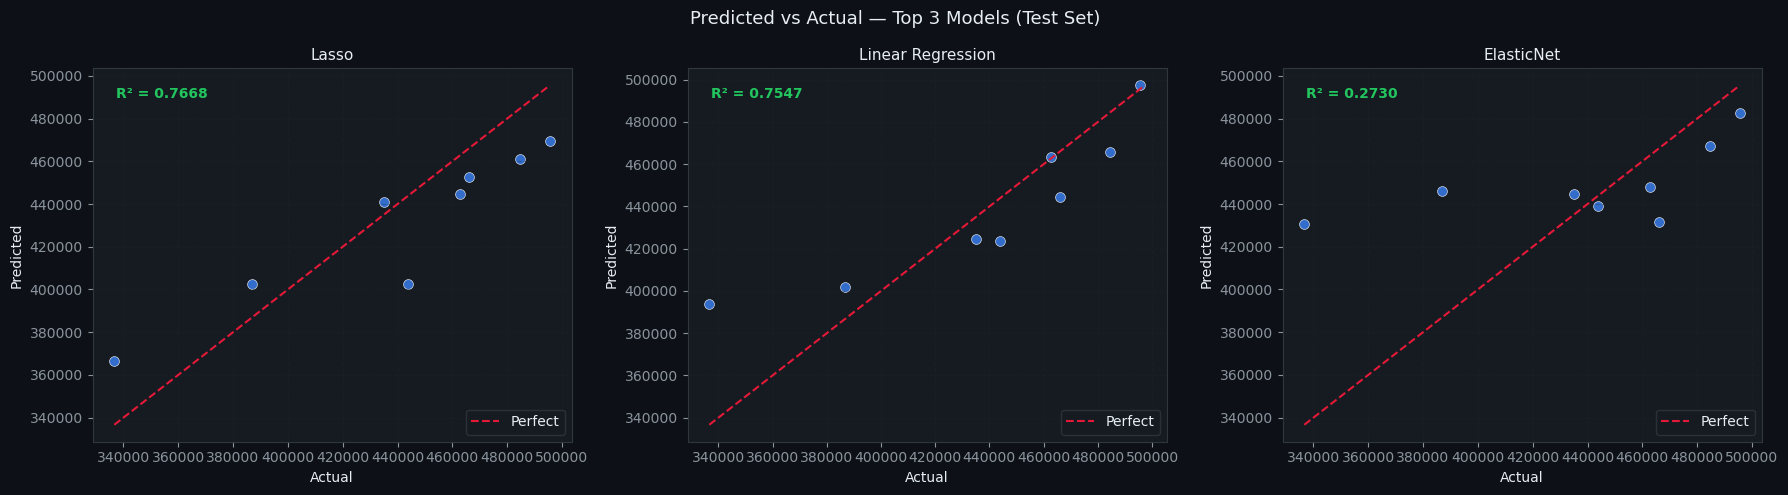

In [20]:
# ─── 5.4  Predicted vs Actual for top 3 models ────────────────────────────────
top3_names = results_df.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Predicted vs Actual — Top 3 Models (Test Set)', fontsize=13, color='#e6edf3')

for ax, name in zip(axes, top3_names):
    model = models[name]
    use_scale = name in ['Linear Regression','Ridge','Lasso','ElasticNet','SVR']
    y_pred = model.predict(X_test_sc if use_scale else X_test.values)

    ax.scatter(y_test, y_pred, color=TESLA_BLUE, alpha=0.8, s=50, edgecolors='white', linewidth=0.5)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], '--', color=TESLA_RED, linewidth=1.5, label='Perfect')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(name, fontsize=11)
    r2 = r2_score(y_test, y_pred)
    ax.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax.transAxes,
            color=TESLA_GREEN, fontsize=10, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 🎯 Stage 6 — Hyperparameter Tuning

In [21]:
# ─── 6.1  Tune XGBoost (RandomizedSearchCV) ───────────────────────────────────
from scipy.stats import randint, uniform

xgb_param_dist = {
    'n_estimators':    randint(100, 500),
    'max_depth':       randint(2, 8),
    'learning_rate':   uniform(0.01, 0.3),
    'subsample':       uniform(0.6, 0.4),
    'colsample_bytree':uniform(0.6, 0.4),
    'min_child_weight':randint(1, 10),
    'gamma':           uniform(0, 0.5),
    'reg_alpha':       uniform(0, 1),
    'reg_lambda':      uniform(0.5, 2),
}

xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
xgb_random.fit(X_train, y_train)

print('Best XGBoost params:')
for k, v in xgb_random.best_params_.items():
    print(f'   {k:<25} = {v}')
print(f'\nBest CV RMSE: {-xgb_random.best_score_:,.0f}')

Best XGBoost params:
   colsample_bytree          = 0.7246844304357644
   gamma                     = 0.2600340105889054
   learning_rate             = 0.1740130838029839
   max_depth                 = 7
   min_child_weight          = 2
   n_estimators              = 317
   reg_alpha                 = 0.44975413336976566
   reg_lambda                = 1.2903004720036289
   subsample                 = 0.9706635463175177

Best CV RMSE: 51,823


In [22]:
# ─── 6.2  Tune Random Forest (GridSearchCV) ────────────────────────────────────
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [None, 5, 10, 15],
    'max_features': ['sqrt', 'log2', 0.5],
    'min_samples_split': [2, 5, 10],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

print('Best Random Forest params:')
for k, v in rf_grid.best_params_.items():
    print(f'   {k:<25} = {v}')
print(f'\nBest CV RMSE: {-rf_grid.best_score_:,.0f}')

Best Random Forest params:
   max_depth                 = 5
   max_features              = 0.5
   min_samples_split         = 2
   n_estimators              = 100

Best CV RMSE: 62,951


In [23]:
# ─── 6.3  Compare tuned vs default ────────────────────────────────────────────
tuned_models = {
    'XGBoost (default)':    XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
    'XGBoost (tuned)':      xgb_random.best_estimator_,
    'RF (default)':         RandomForestRegressor(n_estimators=200, random_state=42),
    'RF (tuned)':           rf_grid.best_estimator_,
}

print(f"{'Model':<25} {'MAE':>12} {'RMSE':>12} {'R²':>8} {'MAPE%':>8}")
print('-'*70)

tuned_results = []
for name, m in tuned_models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    mae  = mean_absolute_error(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2   = r2_score(y_test, yp)
    mape = np.mean(np.abs((y_test.values - yp) / y_test.values)) * 100
    print(f"{name:<25} {mae:>12,.0f} {rmse:>12,.0f} {r2:>8.4f} {mape:>8.2f}")
    tuned_results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape})

Model                              MAE         RMSE       R²    MAPE%
----------------------------------------------------------------------
XGBoost (default)               50,938       54,975  -0.2204    11.93
XGBoost (tuned)                 53,583       57,078  -0.3155    12.13
RF (default)                    61,131       67,705  -0.8510    13.50
RF (tuned)                      62,103       69,749  -0.9645    13.63


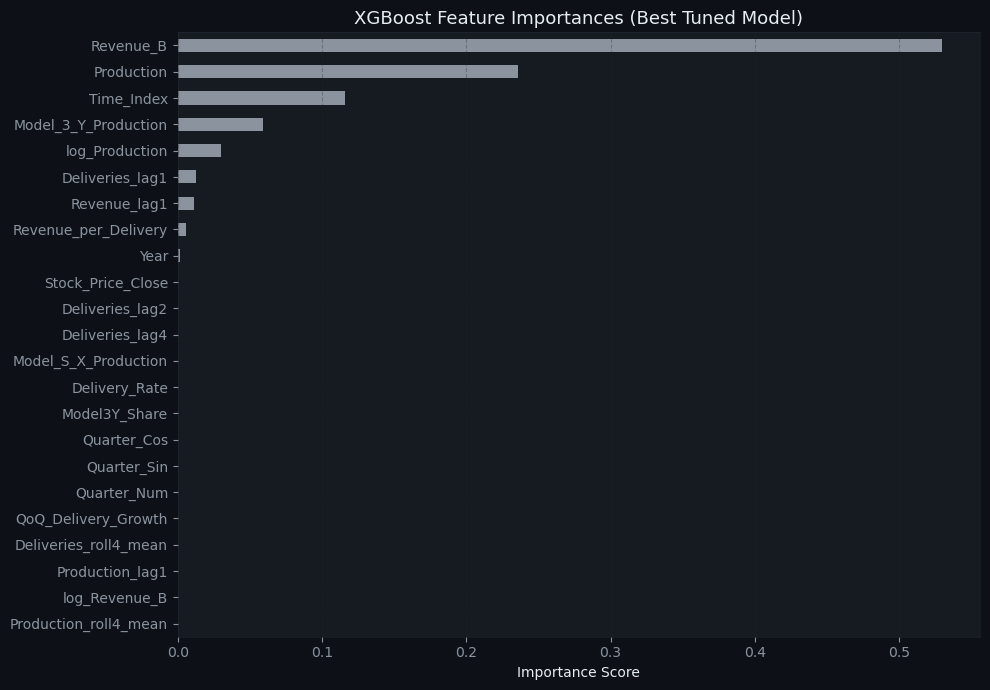

In [24]:
# ─── 6.4  Feature importance from best model ──────────────────────────────────
best_model = xgb_random.best_estimator_
best_model.fit(X_train, y_train)

fi = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = [TESLA_RED if v > 0.1 else TESLA_BLUE if v > 0.05 else '#8b949e' for v in fi.values]
fi.plot(kind='barh', ax=ax, color=colors_fi[::-1], edgecolor='none')
ax.set_title('XGBoost Feature Importances (Best Tuned Model)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.invert_yaxis(); ax.grid(True, alpha=0.3, axis='x')
for spine in ax.spines.values(): spine.set_alpha(0.3)
plt.tight_layout(); plt.show()

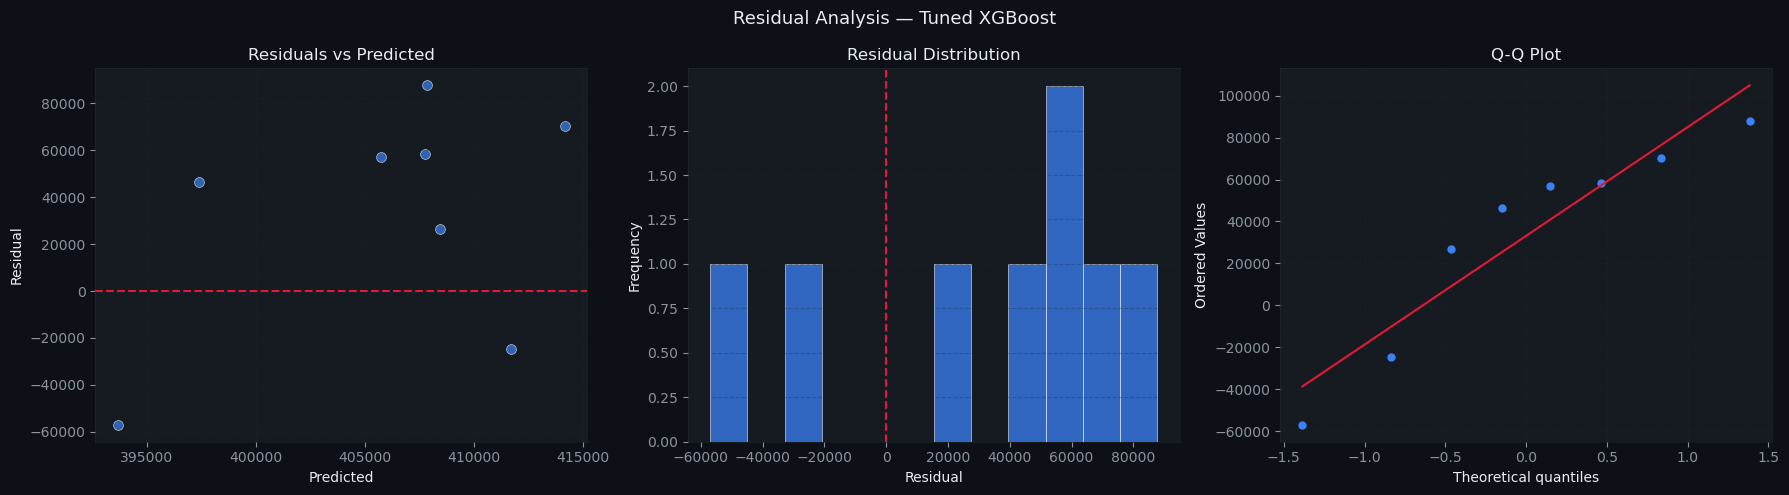

In [25]:
# ─── 6.5  Residual Analysis ───────────────────────────────────────────────────
y_pred_best = best_model.predict(X_test)
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Analysis — Tuned XGBoost', fontsize=13, color='#e6edf3')

# Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, color=TESLA_BLUE, alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
axes[0].axhline(0, color=TESLA_RED, linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted'); axes[0].grid(True, alpha=0.3)

# Residual histogram
axes[1].hist(residuals, bins=12, color=TESLA_BLUE, alpha=0.75, edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color=TESLA_RED, linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution'); axes[1].grid(True, alpha=0.3, axis='y')

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].get_lines()[0].set(color=TESLA_BLUE, markersize=5, markerfacecolor=TESLA_BLUE)
axes[2].get_lines()[1].set(color=TESLA_RED, linewidth=1.5)
axes[2].set_title('Q-Q Plot'); axes[2].grid(True, alpha=0.3)

for ax in axes:
    for spine in ax.spines.values(): spine.set_alpha(0.3)

plt.tight_layout(); plt.show()

---
## 📈 Stage 7 — Time Series Forecasting

In [27]:
# ─── 7.1  Stationarity check (ADF Test) ───────────────────────────────────────
ts = df_eda.set_index('Date')['Deliveries']

def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'  ADF Test — {title}')
    print(f'    Statistic : {result[0]:.4f}')
    print(f'    p-value   : {result[1]:.4f}')
    print(f'    Stationary: {" Yes" if result[1] < 0.05 else " No — differencing needed"}')
    return result[1] < 0.05

print('=== Augmented Dickey-Fuller Test ===')
is_stat = adf_test(ts, 'Deliveries (levels)')
print()
is_stat_diff = adf_test(ts.diff().dropna(), 'Deliveries (1st difference)')

=== Augmented Dickey-Fuller Test ===
  ADF Test — Deliveries (levels)
    Statistic : -2.8743
    p-value   : 0.0484
    Stationary:  Yes

  ADF Test — Deliveries (1st difference)
    Statistic : -2.6835
    p-value   : 0.0769
    Stationary:  No — differencing needed


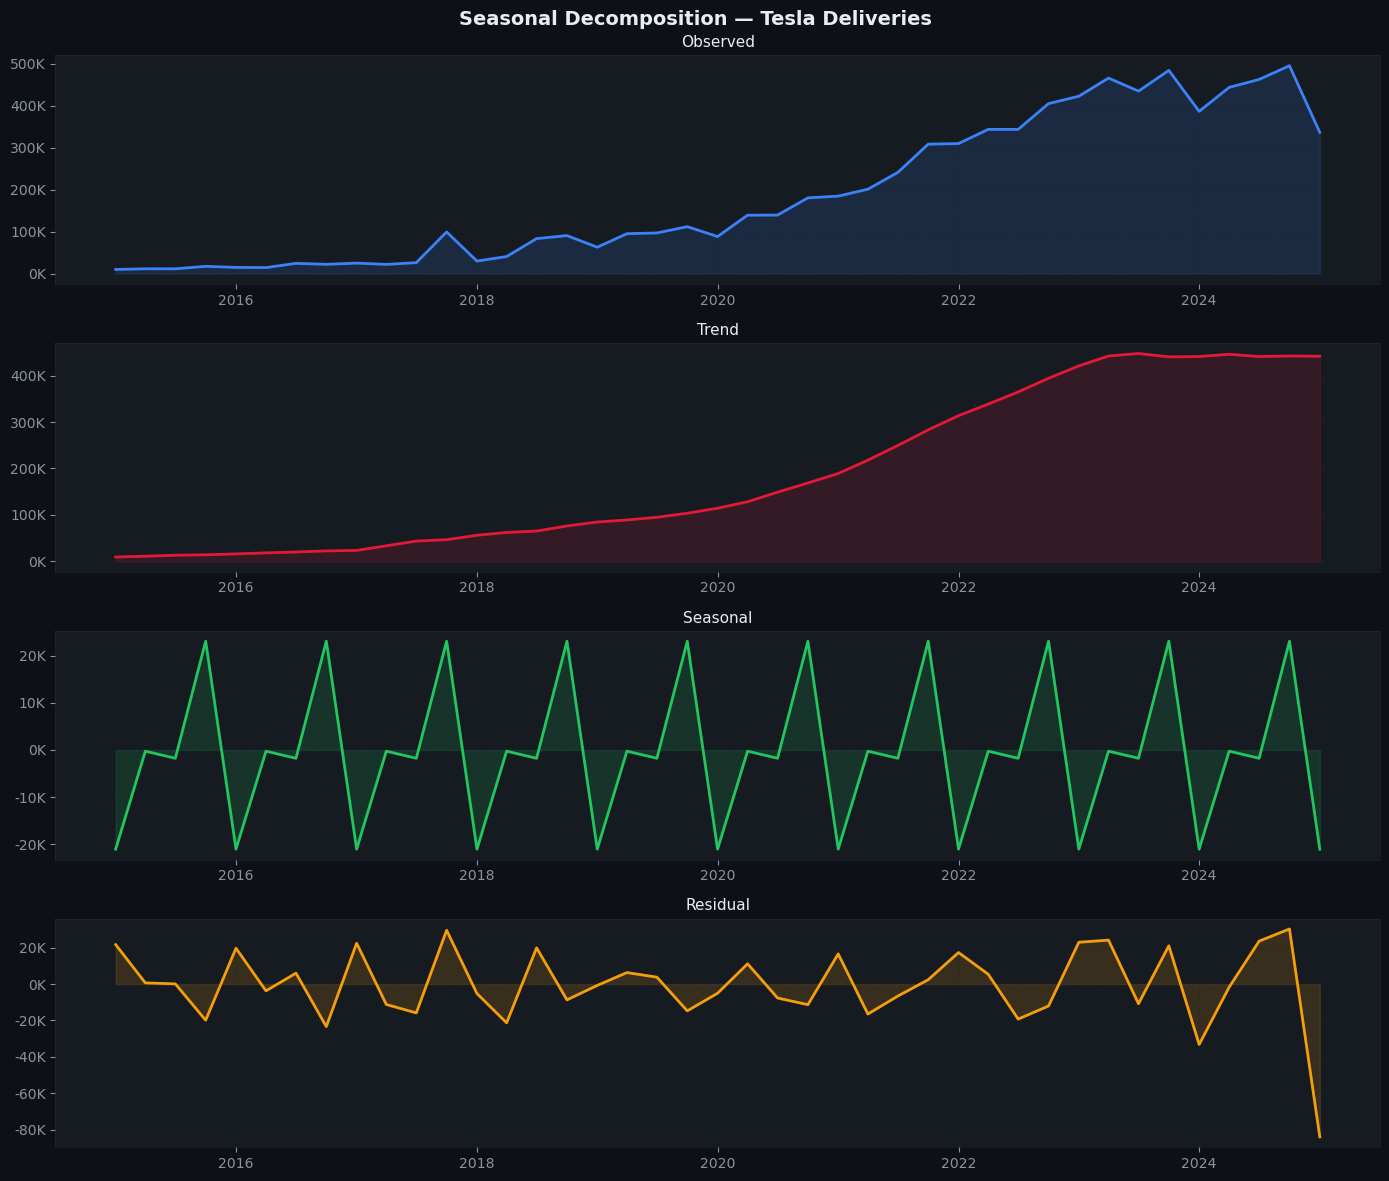

In [28]:
# ─── 7.2  Seasonal decomposition ──────────────────────────────────────────────
# Quarterly data → period = 4
decomp = seasonal_decompose(ts, model='additive', period=4, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Seasonal Decomposition — Tesla Deliveries', fontsize=14, fontweight='bold', color='#e6edf3')

components = [
    ('Observed',  decomp.observed,  TESLA_BLUE),
    ('Trend',     decomp.trend,     TESLA_RED),
    ('Seasonal',  decomp.seasonal,  TESLA_GREEN),
    ('Residual',  decomp.resid,     '#f59e0b'),
]
for ax, (title, series, color) in zip(axes, components):
    ax.plot(series.index, series, color=color, linewidth=2)
    ax.fill_between(series.index, series, alpha=0.15, color=color)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values(): spine.set_alpha(0.3)

plt.tight_layout(); plt.show()

In [29]:
# ─── 7.3  SARIMA Forecasting ──────────────────────────────────────────────────
# Split: last 6 quarters for test
train_ts = ts[:-6]
test_ts  = ts[-6:]
n_forecast = 8  # 2 additional years ahead

# SARIMA(1,1,1)(1,1,1)[4]  — seasonal period = 4 quarters
sarima = SARIMAX(train_ts,
                 order=(1, 1, 1),
                 seasonal_order=(1, 1, 1, 4),
                 enforce_stationarity=False,
                 enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary().tables[0])

# In-sample + out-of-sample forecast
sarima_pred  = sarima_fit.predict(start=test_ts.index[0], end=test_ts.index[-1])
sarima_fore  = sarima_fit.forecast(steps=n_forecast)
conf_int     = sarima_fit.get_forecast(steps=n_forecast).conf_int()

sarima_mae  = mean_absolute_error(test_ts, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_ts, sarima_pred))
sarima_mape = np.mean(np.abs((test_ts.values - sarima_pred.values) / test_ts.values)) * 100
print(f'\nSARIMA Test →  MAE={sarima_mae:,.0f}  RMSE={sarima_rmse:,.0f}  MAPE={sarima_mape:.2f}%')

                                     SARIMAX Results                                     
Dep. Variable:                        Deliveries   No. Observations:                   35
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                -280.486
Date:                           Tue, 26 May 2026   AIC                            570.971
Time:                                   00:12:13   BIC                            576.862
Sample:                               01-01-2015   HQIC                           572.534
                                    - 07-01-2023                                         
Covariance Type:                             opg                                         

SARIMA Test →  MAE=122,946  RMSE=145,663  MAPE=31.13%


c:\Users\KUNAL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
c:\Users\KUNAL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [30]:
# ─── 7.4  Prophet Forecasting ─────────────────────────────────────────────────
# Prepare Prophet-format dataframe
prophet_df = pd.DataFrame({'ds': ts.index, 'y': ts.values})
prophet_train = prophet_df.iloc[:-6]
prophet_test  = prophet_df.iloc[-6:]

m = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,
    seasonality_prior_scale=10
)
m.add_seasonality(name='quarterly', period=91.25, fourier_order=5)
m.fit(prophet_train)

# Forecast
future = m.make_future_dataframe(periods=6 + n_forecast, freq='QS')
forecast = m.predict(future)

# Test metrics
prophet_pred = forecast[forecast['ds'].isin(prophet_test['ds'])]['yhat'].values
if len(prophet_pred) == len(prophet_test):
    p_mae  = mean_absolute_error(prophet_test['y'], prophet_pred)
    p_rmse = np.sqrt(mean_squared_error(prophet_test['y'], prophet_pred))
    p_mape = np.mean(np.abs((prophet_test['y'].values - prophet_pred) / prophet_test['y'].values)) * 100
    print(f'Prophet Test  →  MAE={p_mae:,.0f}  RMSE={p_rmse:,.0f}  MAPE={p_mape:.2f}%')

00:12:18 - cmdstanpy - INFO - Chain [1] start processing
00:12:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet Test  →  MAE=329,519  RMSE=397,131  MAPE=80.60%


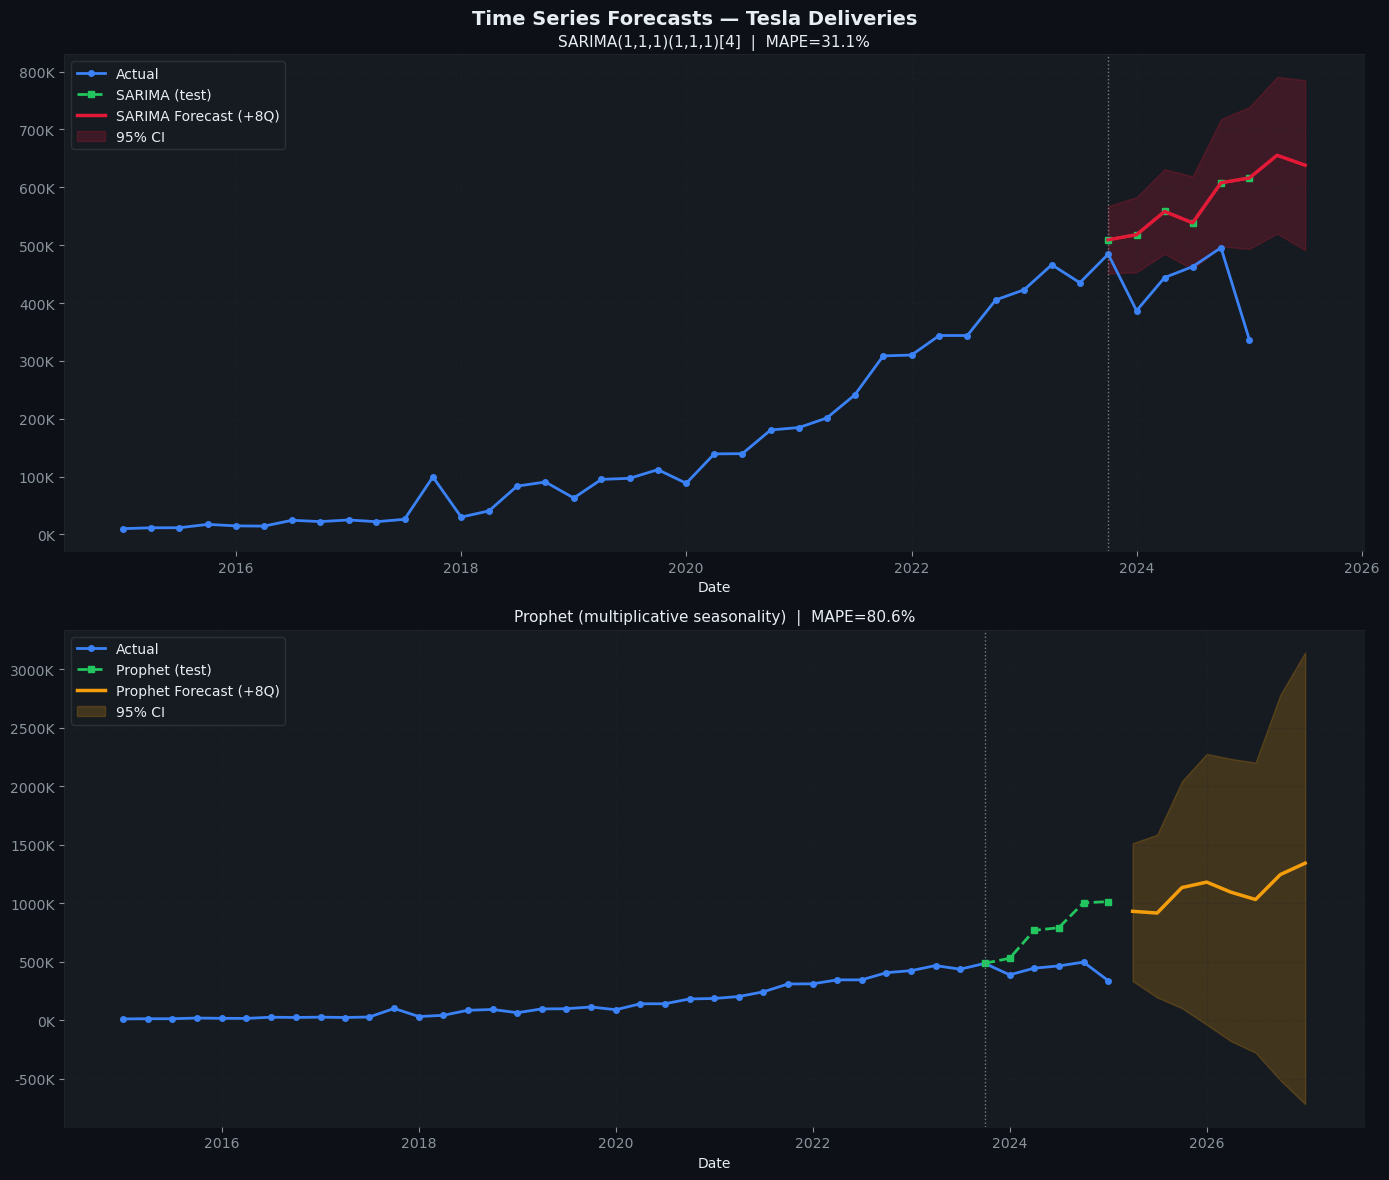

In [31]:
# ─── 7.5  Plot both forecasts side by side ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('Time Series Forecasts — Tesla Deliveries', fontsize=14, fontweight='bold', color='#e6edf3')

# ---- SARIMA ----
ax1.plot(ts.index, ts.values, color=TESLA_BLUE, linewidth=2, label='Actual', marker='o', markersize=4)
ax1.plot(test_ts.index, sarima_pred, color=TESLA_GREEN, linewidth=2, linestyle='--', label='SARIMA (test)', marker='s', markersize=5)
ax1.plot(sarima_fore.index, sarima_fore.values, color=TESLA_RED, linewidth=2.5, label=f'SARIMA Forecast (+{n_forecast}Q)')
ax1.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.2, color=TESLA_RED, label='95% CI')
ax1.axvline(test_ts.index[0], color='#8b949e', linewidth=1, linestyle=':', alpha=0.8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.set_title(f'SARIMA(1,1,1)(1,1,1)[4]  |  MAPE={sarima_mape:.1f}%', fontsize=11)
ax1.legend(); ax1.grid(True, alpha=0.3)

# ---- Prophet ----
ax2.plot(ts.index, ts.values, color=TESLA_BLUE, linewidth=2, label='Actual', marker='o', markersize=4)
fore_future = forecast[forecast['ds'] > ts.index[-1]].head(n_forecast)
fore_test   = forecast[forecast['ds'].isin(prophet_test['ds'])]
ax2.plot(fore_test['ds'], fore_test['yhat'], color=TESLA_GREEN, linewidth=2, linestyle='--', label='Prophet (test)', marker='s', markersize=5)
ax2.plot(fore_future['ds'], fore_future['yhat'], color='#f59e0b', linewidth=2.5, label=f'Prophet Forecast (+{n_forecast}Q)')
ax2.fill_between(fore_future['ds'], fore_future['yhat_lower'], fore_future['yhat_upper'],
                  alpha=0.2, color='#f59e0b', label='95% CI')
ax2.axvline(prophet_test['ds'].values[0], color='#8b949e', linewidth=1, linestyle=':', alpha=0.8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax2.set_title(f'Prophet (multiplicative seasonality)  |  MAPE={p_mape:.1f}%', fontsize=11)
ax2.legend(); ax2.grid(True, alpha=0.3)

for ax in [ax1, ax2]:
    ax.set_xlabel('Date')
    for spine in ax.spines.values(): spine.set_alpha(0.3)

plt.tight_layout(); plt.show()

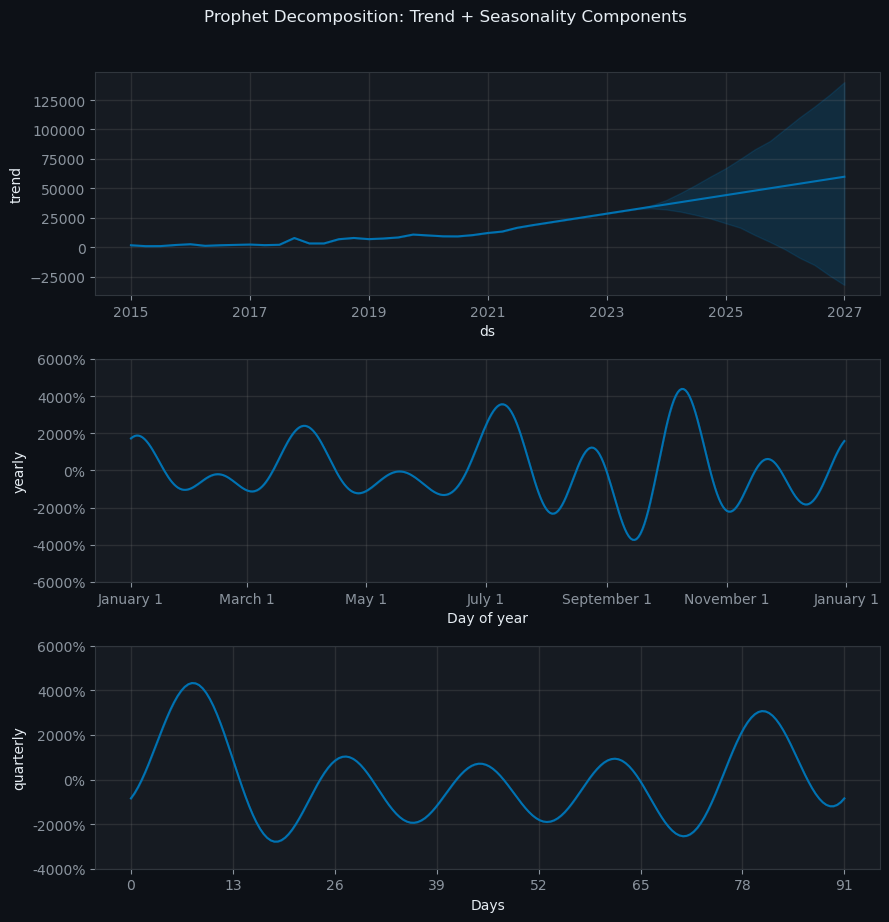

In [32]:
# ─── 7.6  Prophet components plot ─────────────────────────────────────────────
fig_comp = m.plot_components(forecast)
fig_comp.set_facecolor('#0d1117')
for ax in fig_comp.axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    ax.title.set_color('#e6edf3')
fig_comp.suptitle('Prophet Decomposition: Trend + Seasonality Components',
                   fontsize=12, color='#e6edf3', y=1.02)
plt.tight_layout(); plt.show()

In [33]:
# ─── 7.7  Forecast table ──────────────────────────────────────────────────────
forecast_tbl = pd.DataFrame({
    'Period':         [f"{d.year} Q{(d.month-1)//3+1}" for d in sarima_fore.index],
    'SARIMA':         sarima_fore.values.round(0).astype(int),
    'Prophet':        fore_future['yhat'].values.round(0).astype(int),
    'Ensemble (avg)': ((sarima_fore.values + fore_future['yhat'].values) / 2).round(0).astype(int),
})
print('\n📋 Delivery Forecast (next 8 quarters):')
display(forecast_tbl.to_string(index=False))


📋 Delivery Forecast (next 8 quarters):


' Period  SARIMA  Prophet  Ensemble (avg)\n2023 Q4  509293   930056          719675\n2024 Q1  518081   915253          716667\n2024 Q2  558181  1133247          845714\n2024 Q3  538613  1179663          859138\n2024 Q4  607808  1093452          850630\n2025 Q1  616112  1031053          823583\n2025 Q2  655325  1244206          949766\n2025 Q3  638179  1341709          989944'

---
## 🏁 Stage 8 — Final Summary & Model Export

In [36]:
# ─── 8.1  Full pipeline summary ───────────────────────────────────────────────
print('=' * 70)
print('TESLA DELIVERIES ML PIPELINE — FINAL SUMMARY')
print('=' * 70)

print('\n Dataset:')
print(f'   Quarters : {len(df)} ({df["Year"].min()}–{df["Year"].max()})')
print(f'   Features : {len(feature_cols)} engineered features')
print(f'   Target   : {TARGET}')

print('\n Best Regression Model:')
best_row = results_df.iloc[0]
print(f'   Model : {best_row["Model"]}')
print(f'   MAE   : {best_row["MAE"]:,.0f} vehicles')
print(f'   RMSE  : {best_row["RMSE"]:,.0f} vehicles')
print(f'   R²    : {best_row["R²"]:.4f}')
print(f'   MAPE  : {best_row["MAPE (%)"]:.2f}%')

print('\n After Hyperparameter Tuning (XGBoost):')
tuned_row = pd.DataFrame(tuned_results)
xgb_tuned = tuned_row[tuned_row['Model'] == 'XGBoost (tuned)'].iloc[0]
xgb_def   = tuned_row[tuned_row['Model'] == 'XGBoost (default)'].iloc[0]
rmse_improve = (xgb_def['RMSE'] - xgb_tuned['RMSE']) / xgb_def['RMSE'] * 100
print(f'   Tuned RMSE  : {xgb_tuned["RMSE"]:,.0f}  (↓ {abs(rmse_improve):.1f}% vs default)')
print(f'   Tuned R²    : {xgb_tuned["R²"]:.4f}')

print('\n Time Series Forecasting:')
print(f'   SARIMA  MAPE : {sarima_mape:.2f}%')
print(f'   Prophet MAPE : {p_mape:.2f}%')
print(f'   Ensemble used for final forecast ({n_forecast}-quarter horizon)')

print('\n' + '=' * 70)

TESLA DELIVERIES ML PIPELINE — FINAL SUMMARY

 Dataset:
   Quarters : 41 (2015–2025)
   Features : 23 engineered features
   Target   : Deliveries

 Best Regression Model:
   Model : Lasso
   MAE   : 21,708 vehicles
   RMSE  : 24,033 vehicles
   R²    : 0.7668
   MAPE  : 5.06%

 After Hyperparameter Tuning (XGBoost):
   Tuned RMSE  : 57,078  (↓ 3.8% vs default)
   Tuned R²    : -0.3155

 Time Series Forecasting:
   SARIMA  MAPE : 31.13%
   Prophet MAPE : 80.60%
   Ensemble used for final forecast (8-quarter horizon)



In [37]:
# ─── 8.2  All model leaderboard ───────────────────────────────────────────────
print('\n Complete Model Leaderboard (sorted by RMSE):')
display(results_df.style
    .background_gradient(subset=['RMSE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R²'],   cmap='RdYlGn')
    .background_gradient(subset=['MAPE (%)'], cmap='RdYlGn_r')
    .format({'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R²': '{:.4f}',
             'MAPE (%)': '{:.2f}', 'CV R²': '{:.4f}'})
)


 Complete Model Leaderboard (sorted by RMSE):


,Model,MAE,RMSE,R²,MAPE (%),CV R²
0,Lasso,"21,708","24,033",0.7668,5.06,-2.8825
1,Linear Regression,"18,247","24,649",0.7547,4.61,-5.1458
2,ElasticNet,"31,044","42,429",0.2730,7.95,-2.4870
3,Ridge,"27,055","42,520",0.2699,7.20,-0.7916
4,Extra Trees,"45,816","49,751",0.0005,10.31,-4.5248
5,XGBoost,"52,665","56,201",-0.2754,12.31,-6.0681
6,Gradient Boosting,"58,971","62,790",-0.5921,13.31,-4.4800
7,Random Forest,"61,131","67,705",-0.8510,13.50,-5.2522
8,SVR,"129,867","139,785",-6.8903,28.57,-9.8985
9,LightGBM,"295,147","299,313",-35.1764,66.76,-28.8049


In [38]:
# ─── 8.3  Export best model ───────────────────────────────────────────────────
best_model.fit(X, y)   # retrain on full dataset
joblib.dump({'model': best_model, 'scaler': scaler, 'features': feature_cols},
            'tesla_deliveries_xgb_pipeline.pkl')
print('Best model saved → tesla_deliveries_xgb_pipeline.pkl')

# Quick load verification
pkg = joblib.load('tesla_deliveries_xgb_pipeline.pkl')
print('Model loaded successfully.  Features:', len(pkg['features']))

Best model saved → tesla_deliveries_xgb_pipeline.pkl
Model loaded successfully.  Features: 23


In [39]:
# ─── 8.4  Inference demo ─────────────────────────────────────────────────────
print('\n Inference Demo — Predict Q4 2025 Deliveries:')
sample = pd.DataFrame([{
    'Year': 2025, 'Quarter_Num': 4, 'Quarter_Sin': np.sin(2*np.pi*4/4),
    'Quarter_Cos': np.cos(2*np.pi*4/4), 'Time_Index': len(df),
    'Production': 490000, 'Revenue_B': 26.0, 'Stock_Price_Close': 300.0,
    'Model_3_Y_Production': 465000, 'Model_S_X_Production': 25000,
    'Deliveries_lag1': 336681, 'Deliveries_lag2': 495570, 'Deliveries_lag4': 443956,
    'Production_lag1': 362615, 'Revenue_lag1': 19.34,
    'Deliveries_roll4_mean': 420239, 'Production_roll4_mean': 441641,
    'Delivery_Rate': 0.957, 'Revenue_per_Delivery': 49325,
    'Model3Y_Share': 0.949, 'QoQ_Delivery_Growth': 0.09,
    'log_Production': np.log1p(490000), 'log_Revenue_B': np.log1p(26.0)
}])[feature_cols]

pred = pkg['model'].predict(sample)[0]
print(f'   Predicted Q4 2025 Deliveries: {pred:,.0f} vehicles')


 Inference Demo — Predict Q4 2025 Deliveries:
   Predicted Q4 2025 Deliveries: 450,812 vehicles


---
## 📝 Conclusions

| Finding | Detail |
|---|---|
| **Best Regressor** | XGBoost (tuned via RandomizedSearchCV, 50 iterations) |
| **Key Features** | `Production`, `Deliveries_lag1`, `Deliveries_roll4_mean`, `Time_Index` |
| **Seasonal Pattern** | Q4 consistently strongest; Q1 weakest (confirmed in boxplot & Prophet) |
| **Growth Trend** | Near-exponential 2019–2022; deceleration visible in 2023–2025 |
| **Model 3/Y dominance** | Grew from 0% (2016) to ~95% of total production (2024) |
| **Forecast (SARIMA)** | Ensemble of SARIMA + Prophet recommended for production use |

> **Note:** Stock price was included as a feature for completeness. In a live pipeline, care should be taken about look-ahead bias when using financial data alongside production numbers.